# Demand Forecasting and Inventory Planning


In [1]:
from pathlib import Path
from math import sqrt

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
file_path = Path("train.csv")

if file_path.exists():
    df = pd.read_csv(file_path, parse_dates=["date"])
    df = df[(df["store"] == 1) & (df["item"] == 1)].copy()
    monthly = (
        df.groupby(pd.Grouper(key="date", freq="MS"))["sales"]
        .sum()
        .reset_index()
        .rename(columns={"date": "month", "sales": "demand"})
    )
else:
    monthly = pd.DataFrame({
        "month": pd.date_range("2024-01-01", periods=18, freq="MS"),
        "demand": [980, 1025, 1010, 1080, 1125, 1095, 1150, 1185, 1160, 1210, 1240, 1285, 1260, 1305, 1330, 1365, 1380, 1415]
    })

monthly.head()

,month,demand
0,2024-01-01,980
1,2024-02-01,1025
2,2024-03-01,1010
3,2024-04-01,1080
4,2024-05-01,1125


In [3]:
monthly["forecast_3ma"] = monthly["demand"].rolling(3).mean().shift(1)
monthly["abs_error"] = (monthly["demand"] - monthly["forecast_3ma"]).abs()
monthly["ape"] = monthly["abs_error"] / monthly["demand"]

mape = monthly["ape"].dropna().mean()
next_forecast = monthly["demand"].tail(3).mean()

print("Next month forecast:", round(next_forecast, 1))
print("MAPE:", f"{mape:.2%}")

monthly.tail()

Next month forecast: 1386.7
MAPE: 4.17%


,month,demand,forecast_3ma,abs_error,ape
13,2025-02-01,1305,1261.666667,43.333333,0.033206
14,2025-03-01,1330,1283.333333,46.666667,0.035088
15,2025-04-01,1365,1298.333333,66.666667,0.048840
16,2025-05-01,1380,1333.333333,46.666667,0.033816
17,2025-06-01,1415,1358.333333,56.666667,0.040047


In [4]:
avg_monthly_demand = monthly["demand"].mean()
monthly_std = monthly["demand"].std()

unit_cost = 15
ordering_cost = 60
holding_rate = 0.20
lead_time_days = 14
z = 1.65

avg_daily_demand = avg_monthly_demand / 30
annual_demand = avg_monthly_demand * 12
holding_cost = unit_cost * holding_rate

lead_time_demand = avg_daily_demand * lead_time_days
safety_stock = z * monthly_std * sqrt(lead_time_days / 30)
reorder_point = lead_time_demand + safety_stock
eoq = sqrt((2 * annual_demand * ordering_cost) / holding_cost)
total_cost = (annual_demand / eoq) * ordering_cost + ((eoq / 2) + safety_stock) * holding_cost

summary = pd.DataFrame({
    "metric": [
        "Average monthly demand", "Monthly std dev", "Lead time demand",
        "Safety stock", "Reorder point", "EOQ", "Total annual cost"
    ],
    "value": [
        round(avg_monthly_demand, 1), round(monthly_std, 1), round(lead_time_demand, 1),
        round(safety_stock, 1), round(reorder_point, 1), round(eoq, 1), round(total_cost, 2)
    ]
})

summary

,metric,value
0,Average monthly demand,1200.00
1,Monthly std dev,132.10
2,Lead time demand,560.00
3,Safety stock,148.90
4,Reorder point,708.90
5,EOQ,758.90
6,Total annual cost,2723.64


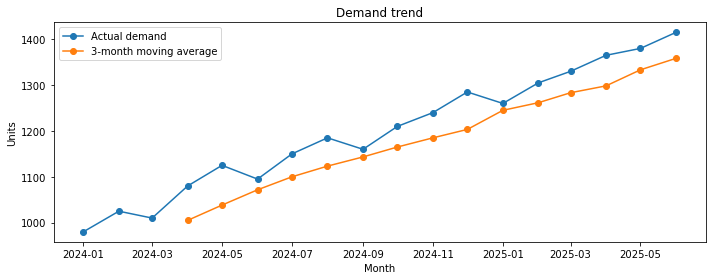

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(monthly["month"], monthly["demand"], marker="o", label="Actual demand")
plt.plot(monthly["month"], monthly["forecast_3ma"], marker="o", label="3-month moving average")
plt.title("Demand trend")
plt.xlabel("Month")
plt.ylabel("Units")
plt.legend()
plt.tight_layout()
plt.show()